## 1. Data Exploration

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [60]:
# Load the dataset
df = pd.read_csv('data.csv')

print("Dataset loaded successfully")
print(f"\nDataset shape: {df.shape}")
print(f"Total records: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")

Dataset loaded successfully

Dataset shape: (569, 33)
Total records: 569
Total features: 33


In [61]:
print("First 5 rows of the dataset:\n")
df.head()

First 5 rows of the dataset:



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [62]:
print("Dataset Information:\n")
print(df.info())
print("\n" + "*"*60)
print("\nData Types:")
print(df.dtypes.value_counts())

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se   

In [63]:
print("Missing Values Analysis:\n")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage': missing_percent.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found in the dataset!")

Missing Values Analysis:

         Column  Missing Count  Percentage
32  Unnamed: 32            569       100.0


In [64]:
print("Target Variable Distribution:\n")
print(df['diagnosis'].value_counts())
print("\n" + "*"*60)
print("\nPercentage Distribution:")
print(df['diagnosis'].value_counts(normalize=True) * 100)

Target Variable Distribution:

diagnosis
B    357
M    212
Name: count, dtype: int64

************************************************************

Percentage Distribution:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


C:\Users\MaitySom\AppData\Local\Temp\ipykernel_31164\1948744319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='Set2')


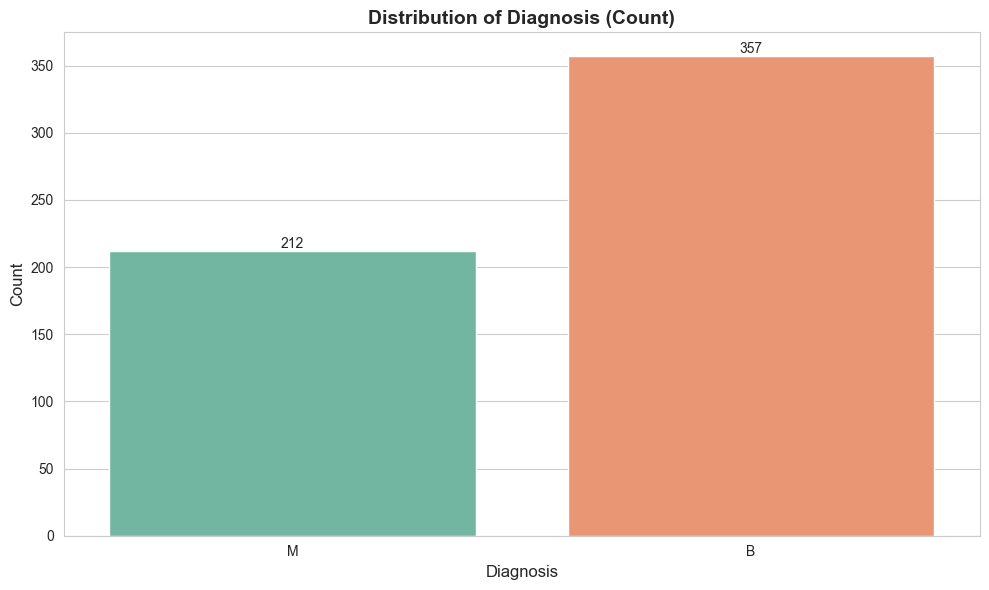

In [65]:
plt.figure(figsize=(10, 6))

# Count plot
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribution of Diagnosis (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Count', fontsize=12)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [66]:
print("Statistical Summary of Numerical Features:\n")
df.describe().T

Statistical Summary of Numerical Features:



,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


## 2. Data Processing

In [67]:
df_processed = df.copy()

print("Original dataset shape:", df_processed.shape)
print("\n" + "*"*60)

Original dataset shape: (569, 33)

************************************************************


In [68]:
columns_to_drop = []

# Drop columns with 'id' or 'unnamed' in name
for col in df_processed.columns:
    if 'id' in col.lower() or 'unnamed' in col.lower():
        columns_to_drop.append(col)
    # Columns that are completely empty
    elif df_processed[col].isnull().all():
        columns_to_drop.append(col)

if columns_to_drop:
    print(f"Dropping irrelevant/empty columns: {columns_to_drop}")
    df_processed = df_processed.drop(columns=columns_to_drop)
    print("Irrelevant columns removed!")
else:
    print("No irrelevant columns found.")

print(f"\nDataset shape after removing irrelevant features: {df_processed.shape}")

remaining_missing = df_processed.isnull().sum().sum()
print(f"Remaining missing values: {remaining_missing}")

Dropping irrelevant/empty columns: ['id', 'Unnamed: 32']
Irrelevant columns removed!

Dataset shape after removing irrelevant features: (569, 31)
Remaining missing values: 0


In [69]:
# Encode categorical variables
# Convert diagnosis: M-> 1 (Malignant), B-> 0 (Benign)

print("Encoding 'diagnosis' column:")
print(f"Before encoding: {df_processed['diagnosis'].unique()}")

df_processed['diagnosis'] = df_processed['diagnosis'].map({'M': 1, 'B': 0})

print(f"After encoding: {df_processed['diagnosis'].unique()}")
print("M -> 1 (Malignant), B -> 0 (Benign)")
print(f"\nEncoded distribution:\n{df_processed['diagnosis'].value_counts()}")

Encoding 'diagnosis' column:
Before encoding: <StringArray>
['M', 'B']
Length: 2, dtype: str
After encoding: [1 0]
M -> 1 (Malignant), B -> 0 (Benign)

Encoded distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [70]:
X = df_processed.drop('diagnosis', axis=1)  # Features
y = df_processed['diagnosis']  # Target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

Features (X) shape: (569, 30)
Target (y) shape: (569,)

Number of features: 30


In [71]:
# Split dataset into Training (80%) and Testing (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [72]:
# Apply feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nSample scaled values (first 5 features of first record):")
print(X_train_scaled[0][:5])


Sample scaled values (first 5 features of first record):
[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]


## 3. Model Development

In [73]:
# Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression model...")
start_time = time.time()

# Initialize and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"Model trained successfully in {training_time:.2f} seconds")
print(f"\nModel Parameters: {lr_model.get_params()}")

Training Logistic Regression model...
Model trained successfully in 0.01 seconds

Model Parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [74]:
# Make predictions with Logistic Regression
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

print(f"\nPredictions on training set: {y_pred_lr_train.shape}")
print(f"Predictions on testing set: {y_pred_lr_test.shape}")


Predictions on training set: (455,)
Predictions on testing set: (114,)


In [75]:
# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest model...")
start_time = time.time()

# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"Model trained successfully in {training_time:.2f} seconds")

Training Random Forest model...


Model trained successfully in 0.15 seconds


In [80]:
# Make predictions with Random Forest
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

print(f"\nPredictions on training set: {y_pred_rf_train.shape}")
print(f"Predictions on testing set: {y_pred_rf_test.shape}")


Predictions on training set: (455,)
Predictions on testing set: (114,)


## 4. Model Evaluation 

In [76]:
# Logistic Regression Evaluation
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Logistic Regression - Training Set Performance
print("*"*60)
print("LOGISTIC REGRESSION - TRAINING SET PERFORMANCE")
print("*"*60)
lr_train_accuracy = accuracy_score(y_train, y_pred_lr_train)
lr_train_precision = precision_score(y_train, y_pred_lr_train)
lr_train_recall = recall_score(y_train, y_pred_lr_train)
lr_train_f1 = f1_score(y_train, y_pred_lr_train)

print(f"Accuracy:  {lr_train_accuracy:.4f} ({lr_train_accuracy*100:.2f}%)")
print(f"Precision: {lr_train_precision:.4f}")
print(f"Recall:    {lr_train_recall:.4f}")
print(f"F1-Score:  {lr_train_f1:.4f}")

# Logistic Regression - Testing Set Performance
print("\n" + "*"*60)
print("LOGISTIC REGRESSION - TESTING SET PERFORMANCE")
print("*"*60)
lr_test_accuracy = accuracy_score(y_test, y_pred_lr_test)
lr_test_precision = precision_score(y_test, y_pred_lr_test)
lr_test_recall = recall_score(y_test, y_pred_lr_test)
lr_test_f1 = f1_score(y_test, y_pred_lr_test)

print(f"Accuracy:  {lr_test_accuracy:.4f} ({lr_test_accuracy*100:.2f}%)")
print(f"Precision: {lr_test_precision:.4f}")
print(f"Recall:    {lr_test_recall:.4f}")
print(f"F1-Score:  {lr_test_f1:.4f}")

************************************************************
LOGISTIC REGRESSION - TRAINING SET PERFORMANCE
************************************************************
Accuracy:  0.9868 (98.68%)
Precision: 1.0000
Recall:    0.9647
F1-Score:  0.9820

************************************************************
LOGISTIC REGRESSION - TESTING SET PERFORMANCE
************************************************************
Accuracy:  0.9649 (96.49%)
Precision: 0.9750
Recall:    0.9286
F1-Score:  0.9512


In [89]:
# Confusion Matrix and Classification Report for Logistic Regression

# Training Set Confusion Matrix
print("*"*60)
print("LOGISTIC REGRESSION - TRAINING SET CONFUSION MATRIX")
print("*"*60)
cm_train = confusion_matrix(y_train, y_pred_lr_train)
print("\nConfusion Matrix:")
print(f"Actual Benign      {cm_train[0][0]:4d}      {cm_train[0][1]:4d}")
print(f"Actual Malignant   {cm_train[1][0]:4d}      {cm_train[1][1]:4d}")

# Testing Set Confusion Matrix
print("\n" + "*"*60)
print("LOGISTIC REGRESSION - TESTING SET CONFUSION MATRIX")
print("*"*60)
cm_test = confusion_matrix(y_test, y_pred_lr_test)
print("\nConfusion Matrix:")
print(f"Actual Benign      {cm_test[0][0]:4d}      {cm_test[0][1]:4d}")
print(f"Actual Malignant   {cm_test[1][0]:4d}      {cm_test[1][1]:4d}")

# Classification Report
print("\n" + "*"*60)
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT (Test Set)")
print("*"*60)
print(classification_report(y_test, y_pred_lr_test, target_names=['Benign (0)', 'Malignant (1)']))

************************************************************
LOGISTIC REGRESSION - TRAINING SET CONFUSION MATRIX
************************************************************

Confusion Matrix:
Actual Benign       285         0
Actual Malignant      6       164

************************************************************
LOGISTIC REGRESSION - TESTING SET CONFUSION MATRIX
************************************************************

Confusion Matrix:
Actual Benign        71         1
Actual Malignant      3        39

************************************************************
LOGISTIC REGRESSION - CLASSIFICATION REPORT (Test Set)
************************************************************
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.9

In [81]:
# Random Forest Evaluation
# Random Forest - Training Set Performance
print("*"*60)
print("RANDOM FOREST - TRAINING SET PERFORMANCE")
print("*"*60)
rf_train_accuracy = accuracy_score(y_train, y_pred_rf_train)
rf_train_precision = precision_score(y_train, y_pred_rf_train)
rf_train_recall = recall_score(y_train, y_pred_rf_train)
rf_train_f1 = f1_score(y_train, y_pred_rf_train)

print(f"Accuracy:  {rf_train_accuracy:.4f} ({rf_train_accuracy*100:.2f}%)")
print(f"Precision: {rf_train_precision:.4f}")
print(f"Recall:    {rf_train_recall:.4f}")
print(f"F1-Score:  {rf_train_f1:.4f}")

# Random Forest - Testing Set Performance
print("\n" + "*"*60)
print("RANDOM FOREST - TESTING SET PERFORMANCE")
print("*"*60)
rf_test_accuracy = accuracy_score(y_test, y_pred_rf_test)
rf_test_precision = precision_score(y_test, y_pred_rf_test)
rf_test_recall = recall_score(y_test, y_pred_rf_test)
rf_test_f1 = f1_score(y_test, y_pred_rf_test)

print(f"Accuracy:  {rf_test_accuracy:.4f} ({rf_test_accuracy*100:.2f}%)")
print(f"Precision: {rf_test_precision:.4f}")
print(f"Recall:    {rf_test_recall:.4f}")
print(f"F1-Score:  {rf_test_f1:.4f}")

************************************************************
RANDOM FOREST - TRAINING SET PERFORMANCE
************************************************************
Accuracy:  1.0000 (100.00%)
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

************************************************************
RANDOM FOREST - TESTING SET PERFORMANCE
************************************************************
Accuracy:  0.9737 (97.37%)
Precision: 1.0000
Recall:    0.9286
F1-Score:  0.9630


In [84]:
# Confusion Matrix and Classification Report for Random Forest

# Training Set Confusion Matrix
print("*"*60)
print("RANDOM FOREST - TRAINING SET CONFUSION MATRIX")
print("*"*60)
cm_train_rf = confusion_matrix(y_train, y_pred_rf_train)
print("\nConfusion Matrix:")
print(f"Actual Benign      {cm_train_rf[0][0]:4d}      {cm_train_rf[0][1]:4d}")
print(f"Actual Malignant   {cm_train_rf[1][0]:4d}      {cm_train_rf[1][1]:4d}")

# Testing Set Confusion Matrix
print("\n" + "*"*60)
print("RANDOM FOREST - TESTING SET CONFUSION MATRIX")
print("*"*60)
cm_test_rf = confusion_matrix(y_test, y_pred_rf_test)
print("\nConfusion Matrix:")
print(f"Actual Benign      {cm_test_rf[0][0]:4d}      {cm_test_rf[0][1]:4d}")
print(f"Actual Malignant   {cm_test_rf[1][0]:4d}      {cm_test_rf[1][1]:4d}")

# Classification Report
print("\n" + "*"*60)
print("RANDOM FOREST - CLASSIFICATION REPORT (Test Set)")
print("*"*60)
print(classification_report(y_test, y_pred_rf_test, target_names=['Benign (0)', 'Malignant (1)']))

************************************************************
RANDOM FOREST - TRAINING SET CONFUSION MATRIX
************************************************************

Confusion Matrix:
Actual Benign       285         0
Actual Malignant      0       170

************************************************************
RANDOM FOREST - TESTING SET CONFUSION MATRIX
************************************************************

Confusion Matrix:
Actual Benign        72         0
Actual Malignant      3        39

************************************************************
RANDOM FOREST - CLASSIFICATION REPORT (Test Set)
************************************************************
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0

## 5. Results and Interpretations

In [85]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:\n")
print(feature_importance.head(10))

Top 10 Most Important Features:

                 Feature  Importance
23            area_worst    0.151412
27  concave points_worst    0.126497
20          radius_worst    0.093475
22       perimeter_worst    0.083642
7    concave points_mean    0.081082
2         perimeter_mean    0.077126
0            radius_mean    0.061990
6         concavity_mean    0.050818
3              area_mean    0.045916
26       concavity_worst    0.030022


In [86]:
# Sample predictions on test set
sample_indices = [0, 5, 10, 15, 20]

print("Sample Predictions from Test Set:")
print("*"*80)

for i in sample_indices:
    actual = y_test.iloc[i]
    lr_pred = y_pred_lr_test[i]
    rf_pred = y_pred_rf_test[i]
    
    # Get probability scores
    lr_prob = lr_model.predict_proba(X_test_scaled[i].reshape(1, -1))[0]
    rf_prob = rf_model.predict_proba(X_test_scaled[i].reshape(1, -1))[0]
    
    print(f"\nSample {i+1}:")
    print(f"  Actual:              {'Malignant (1)' if actual == 1 else 'Benign (0)'}")
    print(f"  Logistic Regression: {'Malignant (1)' if lr_pred == 1 else 'Benign (0)'} (Confidence: {max(lr_prob)*100:.2f}%)")
    print(f"  Random Forest:       {'Malignant (1)' if rf_pred == 1 else 'Benign (0)'} (Confidence: {max(rf_prob)*100:.2f}%)")
    print(f"  Status:              {'✓ CORRECT' if actual == lr_pred == rf_pred else '✗ MISMATCH'}")

Sample Predictions from Test Set:
********************************************************************************

Sample 1:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 99.96%)
  Random Forest:       Benign (0) (Confidence: 99.00%)
  Status:              ✓ CORRECT

Sample 6:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 99.94%)
  Random Forest:       Benign (0) (Confidence: 94.00%)
  Status:              ✓ CORRECT

Sample 11:
  Actual:              Malignant (1)
  Logistic Regression: Malignant (1) (Confidence: 93.09%)
  Random Forest:       Malignant (1) (Confidence: 98.00%)
  Status:              ✓ CORRECT

Sample 16:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 100.00%)
  Random Forest:       Benign (0) (Confidence: 100.00%)
  Status:              ✓ CORRECT

Sample 21:
  Actual:              Benign (0)
  Logistic Regression: Benign (0) (Confidence: 99.87%)
  Random Forest:   

## Model Comparison


In [87]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression (Train)': [lr_train_accuracy, lr_train_precision, lr_train_recall, lr_train_f1],
    'Logistic Regression (Test)': [lr_test_accuracy, lr_test_precision, lr_test_recall, lr_test_f1],
    'Random Forest (Train)': [rf_train_accuracy, rf_train_precision, rf_train_recall, rf_train_f1],
    'Random Forest (Test)': [rf_test_accuracy, rf_test_precision, rf_test_recall, rf_test_f1]
})

print("Model Performance Comparison:")
print("*"*80)
print(comparison_df.to_string(index=False))
print("\n" + "*"*80)

Model Performance Comparison:
********************************************************************************
   Metric  Logistic Regression (Train)  Logistic Regression (Test)  Random Forest (Train)  Random Forest (Test)
 Accuracy                     0.986813                    0.964912                    1.0              0.973684
Precision                     1.000000                    0.975000                    1.0              1.000000
   Recall                     0.964706                    0.928571                    1.0              0.928571
 F1-Score                     0.982036                    0.951220                    1.0              0.962963

********************************************************************************
